# 📺 Netflix Data Analysis — EDA Project

This notebook performs a complete Exploratory Data Analysis (EDA) on the Netflix Titles dataset to uncover patterns and insights about content type, origin, release trends, genres, and ratings.

---

**Tools Used:** pandas · matplotlib · seaborn  
**Dataset:** [Netflix Movies and TV Shows — Kaggle](https://www.kaggle.com/datasets/shivamb/netflix-shows)


In [11]:
# ── Imports ──────────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter

%matplotlib inline

# ── Professional Netflix-themed style ────────────────────────
NETFLIX_RED   = "#E50914"
NETFLIX_DARK  = "#221F1F"
ACCENT        = "#B81D24"
PALETTE_10    = ["#E50914","#B81D24","#F5A623","#F8D210","#2ECC71",
                 "#1ABC9C","#3498DB","#9B59B6","#E67E22","#95A5A6"]

plt.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : "#FAFAFA",
    "axes.edgecolor"   : "#CCCCCC",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.titlesize"   : 14,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 11,
    "xtick.labelsize"  : 10,
    "ytick.labelsize"  : 10,
    "font.family"      : "DejaVu Sans",
    "grid.color"       : "#E5E5E5",
    "grid.linewidth"   : 0.8,
})

print("✅ Libraries loaded & style configured.")


✅ Libraries loaded & style configured.


## 📥 Step 1 — Load the Dataset
We load the Netflix Titles dataset and set `show_id` as the index.

In [12]:
data = pd.read_csv("netflix_titles.csv", index_col="show_id")
print(f"Dataset shape: {data.shape}")
data.head()


Dataset shape: (8807, 11)


,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
show_id,,,,,,,,,,,
s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## 🔍 Step 2 — Understand the Data
Checking structure, data types, and missing values before cleaning.

In [13]:
print("── Shape ──────────────────────────")
print(f"Rows: {data.shape[0]:,}  |  Columns: {data.shape[1]}")

print("\n── Data Types ─────────────────────")
print(data.dtypes)

print("\n── Missing Values ─────────────────")
missing = data.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0])


── Shape ──────────────────────────
Rows: 8,807  |  Columns: 11

── Data Types ─────────────────────
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

── Missing Values ─────────────────
director      2634
country        831
cast           825
date_added      10
rating           4
duration         3
dtype: int64


## 🧹 Step 3 — Data Cleaning
- Fill missing `country` with `"Unknown"` (preserve data instead of dropping)
- Strip and parse `date_added` to datetime, extract `year_added`
- Drop `director` and `cast` (not needed for this analysis)
- Drop rows where `rating` is missing (only 4 rows)


In [14]:
# Fill missing country instead of dropping
data['country'] = data['country'].fillna("Unknown")

# Strip whitespace and parse date_added
data['date_added'] = pd.to_datetime(data['date_added'].str.strip(), format='%B %d, %Y', errors='coerce')

# Extract year_added
data['year_added'] = data['date_added'].dt.year

# Drop rows with missing rating (only 4 rows)
data = data.dropna(subset=['rating'])

# Drop columns not needed
data = data.drop(columns=['director', 'cast'])

print(f"✅ Cleaned dataset shape: {data.shape}")
data.head()


✅ Cleaned dataset shape: (8803, 10)


,type,title,country,date_added,release_year,rating,duration,listed_in,description,year_added
show_id,,,,,,,,,,
s1,Movie,Dick Johnson Is Dead,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0
s2,TV Show,Blood & Water,South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0
s3,TV Show,Ganglands,Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0
s4,TV Show,Jailbirds New Orleans,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0
s5,TV Show,Kota Factory,India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0


## 📊 Q1 — Movies vs TV Shows Distribution
Is Netflix more film-heavy or series-heavy?

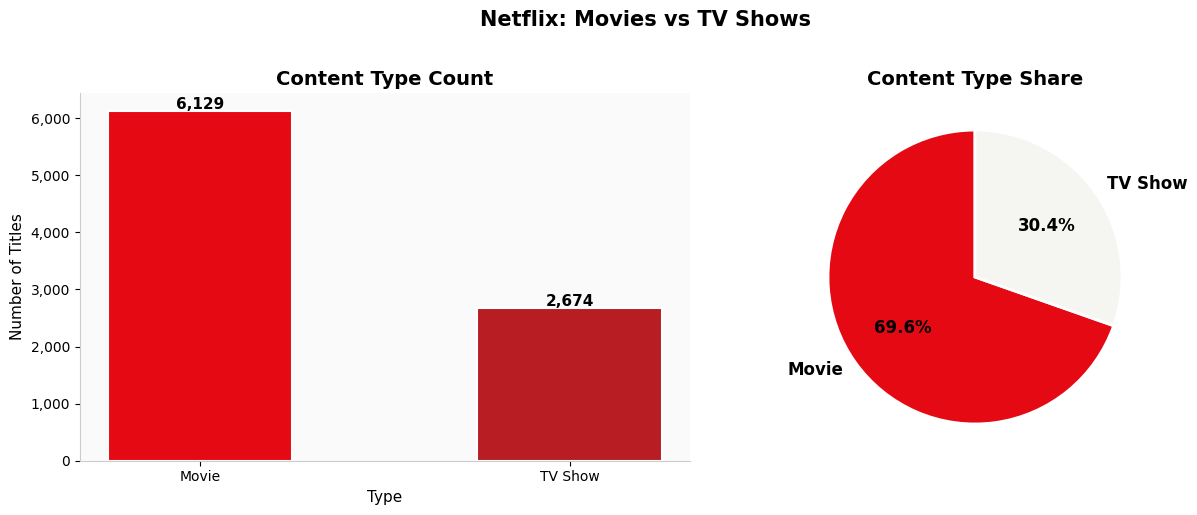

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
counts = data['type'].value_counts()
bars = axes[0].bar(counts.index, counts.values,
                   color=[NETFLIX_RED, ACCENT], width=0.5, edgecolor='white', linewidth=1.5)
axes[0].set_title("Content Type Count")
axes[0].set_xlabel("Type")
axes[0].set_ylabel("Number of Titles")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{int(bar.get_height()):,}', ha='center', fontweight='bold', fontsize=11)

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=[NETFLIX_RED, "#F5F5F1"], startangle=90,
            textprops={'fontsize': 12, 'fontweight': 'bold'},
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title("Content Type Share")

plt.suptitle("Netflix: Movies vs TV Shows", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**📌 Insight:** Netflix hosts ~70% Movies vs ~30% TV Shows, indicating a clearly film-heavy content strategy.

## 🌍 Q2 — Top 10 Content-Producing Countries
Which countries contribute the most titles to Netflix?

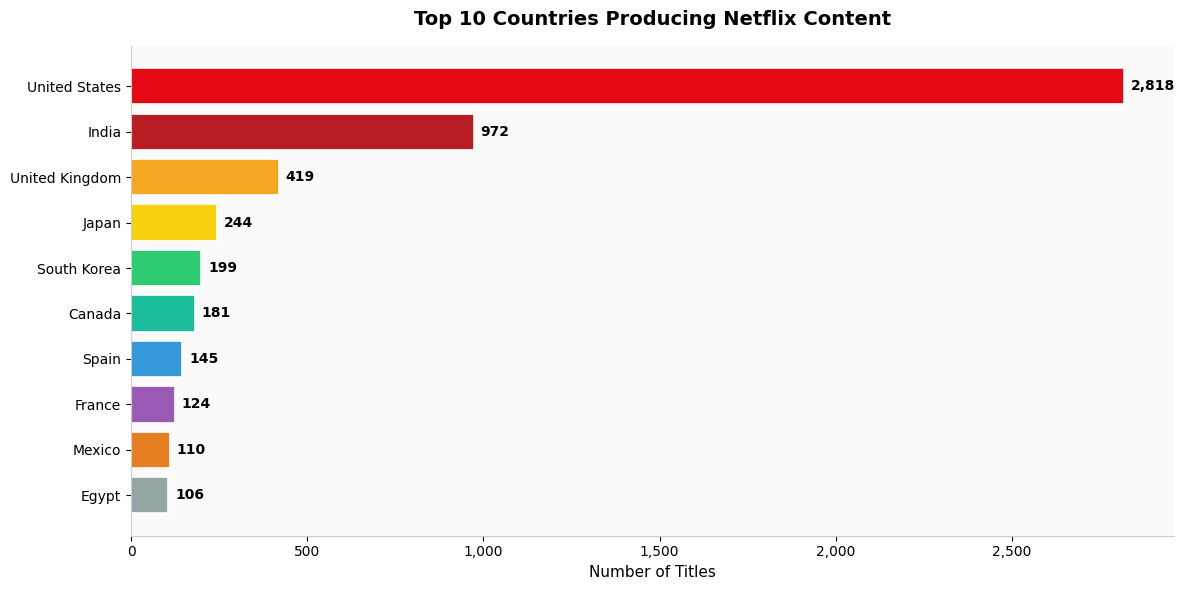

In [16]:
top_countries = data[data['country'] != 'Unknown']['country'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_countries.index[::-1], top_countries.values[::-1],
               color=PALETTE_10[::-1], edgecolor='white', linewidth=1.2)

for bar in bars:
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width()):,}', va='center', fontsize=10, fontweight='bold')

ax.set_title("Top 10 Countries Producing Netflix Content", pad=15)
ax.set_xlabel("Number of Titles")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()


**📌 Insight:** The USA dominates Netflix content production by a massive margin, followed by India and the UK — reflecting both market size and production investment.

## 📅 Q3 — Netflix Content Growth Over the Years
How has the volume of content added to Netflix changed over time?

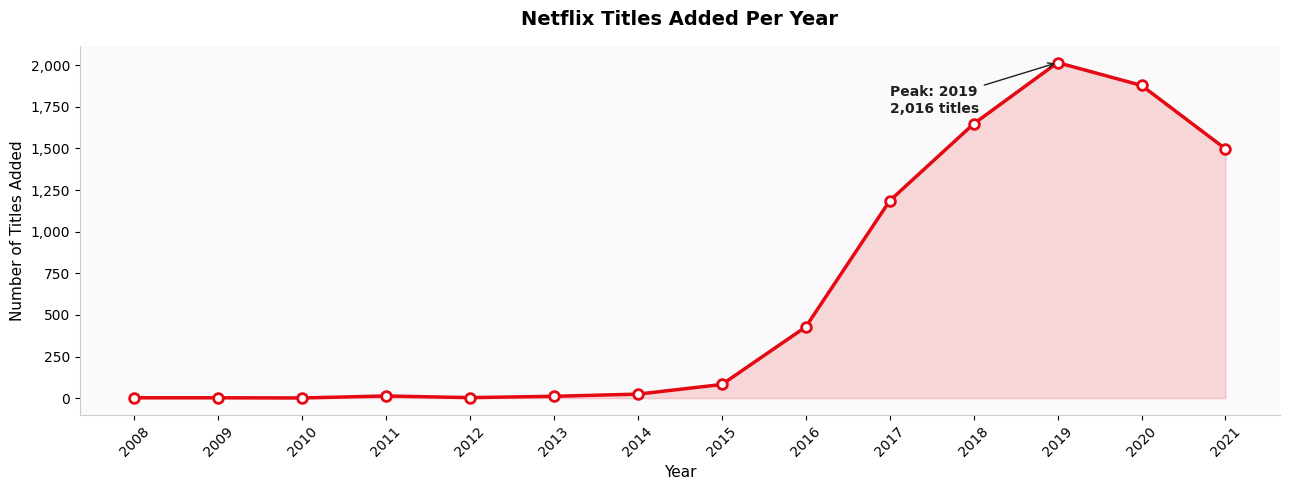

In [17]:
yearly = data['year_added'].value_counts().sort_index().dropna()
yearly.index = yearly.index.astype(int)

fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(yearly.index, yearly.values, alpha=0.15, color=NETFLIX_RED)
ax.plot(yearly.index, yearly.values, marker='o', color=NETFLIX_RED,
        linewidth=2.5, markersize=7, markerfacecolor='white', markeredgewidth=2)

# Annotate peak
peak_year = yearly.idxmax()
ax.annotate(f'Peak: {peak_year}\n{yearly[peak_year]:,} titles',
            xy=(peak_year, yearly[peak_year]),
            xytext=(peak_year - 2, yearly[peak_year] - 300),
            arrowprops=dict(arrowstyle='->', color=NETFLIX_DARK),
            fontsize=10, fontweight='bold', color=NETFLIX_DARK)

ax.set_title("Netflix Titles Added Per Year", pad=15)
ax.set_xlabel("Year")
ax.set_ylabel("Number of Titles Added")
ax.set_xticks(yearly.index)
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()


**📌 Insight:** Netflix aggressively expanded its library from 2015 to 2019, peaking in 2019. A visible dip after 2019 reflects the COVID-19 pandemic's disruption to global content production pipelines.

## 🎭 Q4 — Most Common Genres on Netflix
What types of content dominate the Netflix library?

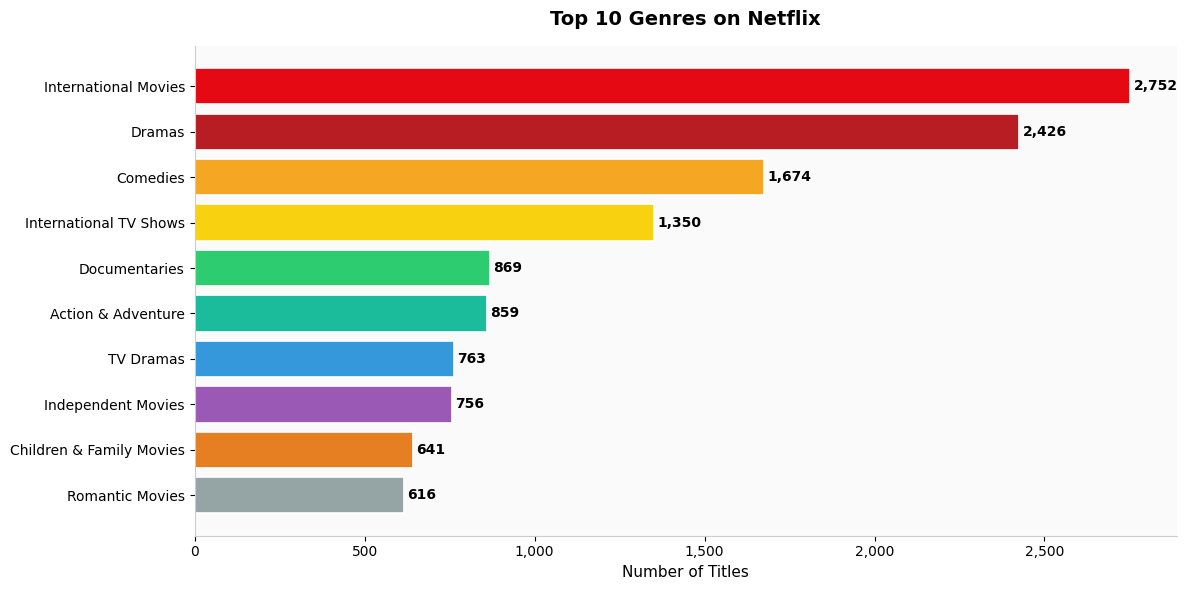

In [18]:
all_genres = ', '.join(data['listed_in'].dropna()).split(', ')
genre_counts = Counter(all_genres)
top_genres = pd.DataFrame(genre_counts.most_common(10), columns=['Genre', 'Count'])

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_genres['Genre'][::-1], top_genres['Count'][::-1],
               color=PALETTE_10[::-1], edgecolor='white', linewidth=1.2)

for bar in bars:
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width()):,}', va='center', fontsize=10, fontweight='bold')

ax.set_title("Top 10 Genres on Netflix", pad=15)
ax.set_xlabel("Number of Titles")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()


**📌 Insight:** International Movies, Dramas, and Comedies dominate Netflix's genre catalog — highlighting both global reach and appetite for story-driven content.

## 🔞 Q5 — Most Common Content Ratings
What age-group is most of Netflix's content targeted at?

C:\Users\GOPU\AppData\Local\Temp\ipykernel_352\2414906366.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='rating', order=rating_order,


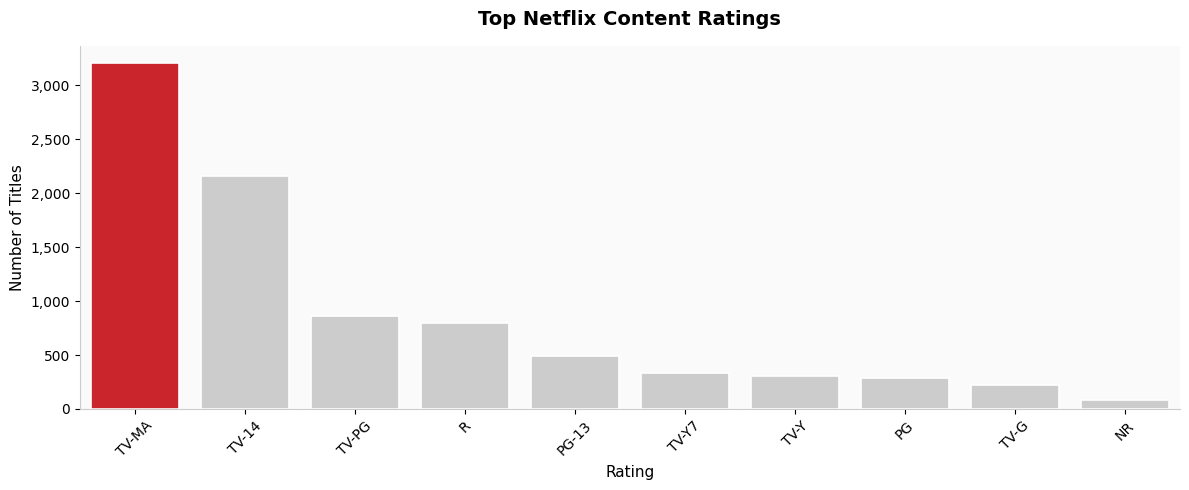

In [19]:
fig, ax = plt.subplots(figsize=(12, 5))
rating_order = data['rating'].value_counts().index[:10]
palette = [NETFLIX_RED if i == 0 else "#CCCCCC" for i in range(len(rating_order))]

sns.countplot(data=data, x='rating', order=rating_order,
              palette=palette, edgecolor='white', linewidth=1.2, ax=ax)

ax.set_title("Top Netflix Content Ratings", pad=15)
ax.set_xlabel("Rating")
ax.set_ylabel("Number of Titles")
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()


**📌 Insight:** TV-MA (Mature Audiences) is the most common rating by a wide margin, showing Netflix's strong focus on adult-targeted content — likely to differentiate from traditional broadcast TV.

## 🎬 Q6 — Movies vs TV Shows Added Each Year
How has the content type mix evolved over time?

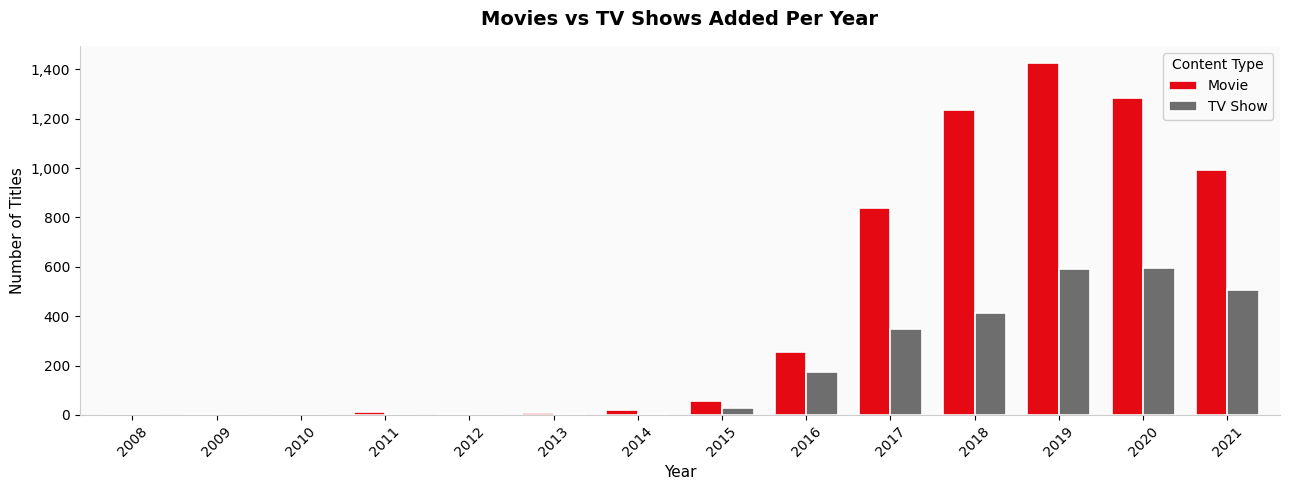

In [20]:
yearly_type = data.groupby(['year_added', 'type']).size().unstack(fill_value=0)
yearly_type.index = yearly_type.index.astype(int)

fig, ax = plt.subplots(figsize=(13, 5))
yearly_type.plot(kind='bar', ax=ax, color=[NETFLIX_RED, "#6E6E6E"],
                 edgecolor='white', linewidth=1.2, width=0.75)

ax.set_title("Movies vs TV Shows Added Per Year", pad=15)
ax.set_xlabel("Year")
ax.set_ylabel("Number of Titles")
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(title="Content Type", framealpha=0.9)
plt.tight_layout()
plt.show()


**📌 Insight:** Movies consistently outnumber TV Shows each year. However, TV Show additions grew notably after 2016, suggesting Netflix's strategic investment in original series.

## 🧾 Conclusion

| # | Finding | Insight |
|---|---------|---------|
| 1 | ~70% of content is Movies | Netflix is primarily a film platform |
| 2 | USA, India, UK lead production | Content investment mirrors market priorities |
| 3 | Peak growth was 2019 | COVID-19 disrupted post-2019 additions |
| 4 | International Movies & Dramas dominate | Global, story-driven content wins |
| 5 | TV-MA is the top rating | Focus on adult audiences differentiates from broadcast TV |
| 6 | TV Show additions grew after 2016 | Strategic shift toward original series |

---

🎯 **Skills Demonstrated in this Project:**
- Data wrangling with **pandas**
- Professional data visualization with **matplotlib** & **seaborn**
- Deriving business insights from real-world structured data
- Exploratory Data Analysis (EDA) best practices
